In [1]:
import matplotlib
import matplotlib.pyplot as plt
import numpy as np
import os
from pathlib import Path
import shutil

from astropy.nddata import CCDData
from astropy.stats import SigmaClip, mad_std
from astropy import units as u
from astropy.table import QTable
from astropy.io import fits
from astropy.wcs import WCS

import ccdproc as ccdp

import sep

matplotlib.rcParams.update({'font.size': 12})

STRIDE = 10

%matplotlib inline

### Locate all images

In [2]:
read_path = '/home/evanmayer/TIM_data/test_events/TIMcam/flight_test/solve/'
wcs_dir = '/home/evanmayer/TIM_data/test_events/TIMcam/flight_test/solve/'
img_table_solved = QTable.read(read_path + 'tabulated_solved.fits')

In [3]:
default_gain = abs(img_table_solved['GAINFACT'] - 2.0) < 1e-3
default_exp = abs(img_table_solved['EXPTIME'] - 0.2 * u.s) < 1e-3 * u.s
solved = img_table_solved['SOLVED'] > 0
daytime_float = []
for fname in img_table_solved['FILES']:
    if (
        ('10-01_18' in fname)
        or ('10-01_19' in fname)
        or ('10-01_20' in fname)
        or ('10-01_21' in fname)
        or ('10-01_22' in fname)
        or ('10-01_23' in fname)
        or ('10-02_00' in fname)
    ):
        daytime_float.append(True)
        # print(fname)
    else:
        daytime_float.append(False)
daytime_float = np.array(daytime_float)
candidates = (default_gain & default_exp & daytime_float & solved)

In [4]:
# reduced data path
direc = '/home/evanmayer/TIM_data/test_events/TIMcam/flight_test/cal/'
calibrated_data = Path(direc)
calibrated_data.mkdir(exist_ok=True)

In [25]:
img_table_solved[candidates]

FOCUSMIN,FOCUS,FOCUSMAX,GAINFACT,EXPTIME,UTC-SEC,UTC-USEC,CCDTEMP,FILES,SOLVE_ATTEMPTED,SOLVED,FILESIZE,TIMESTAMP,RA,DEC,ORIENTATION,SCALE,N_STARS_FOUND,N_STARS_MATCHED,RMSE,BKG_MED,BKG_MEAN
,,,,s,s,s,deg_C,,,,,s,deg,deg,deg,arcsec / pix,,,arcsec,,
float64,float64,float64,float64,float64,float64,float64,float64,bytes57,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64
-7487.0,-12.0,409.0,2.0,0.2000071,1759342644.0,0.056638,16.375,/media/shared/img/saved_image_2025-10-01_18-17-24.fits.fz,1.0,1.0,14653440.0,1759342644.056638,240.75457277599625,53.91631709249049,84.4786675924599,6.799,27.0,18.0,3.110209073106691,nan,628.6942138671875
-7487.0,-12.0,409.0,2.0,0.2000071,1759342645.0,0.5693889999999999,16.375,/media/shared/img/saved_image_2025-10-01_18-17-25.fits.fz,1.0,1.0,15724800.0,1759342645.569389,240.7143227347743,53.97059936304778,84.40553138583239,6.79889,33.0,20.0,3.8750415656712023,nan,1258.3642578125
-7487.0,-12.0,409.0,2.0,0.2000071,1759342647.0,0.07417699999999999,16.375,/media/shared/img/saved_image_2025-10-01_18-17-27.fits.fz,1.0,1.0,15724800.0,1759342647.074177,240.64410241047074,54.01167199977393,85.0974330675707,6.80062,30.0,12.0,3.441741594036844,nan,1257.9871826171875
-7487.0,-12.0,409.0,2.0,0.2000071,1759342648.0,0.5743969999999999,16.375,/media/shared/img/saved_image_2025-10-01_18-17-28.fits.fz,1.0,1.0,15721920.0,1759342648.574397,240.5457703012105,54.03646135928026,84.31435399352563,6.79983,34.0,21.0,3.8014867960917367,nan,1256.7994384765625
-7487.0,-12.0,409.0,2.0,0.2000071,1759342650.0,0.07832399999999999,16.375,/media/shared/img/saved_image_2025-10-01_18-17-30.fits.fz,1.0,1.0,15719040.0,1759342650.078324,240.44889227149685,54.04543536834262,84.10400472195957,6.79762,38.0,23.0,4.154817844113176,nan,1255.831298828125
-7487.0,-12.0,409.0,2.0,0.2000071,1759342651.0,0.587139,16.375,/media/shared/img/saved_image_2025-10-01_18-17-31.fits.fz,1.0,1.0,15719040.0,1759342651.587139,240.35798974929034,54.056706961430116,85.031312789104,6.79928,43.0,13.0,3.3826853809562123,nan,1254.68359375
-7487.0,-12.0,409.0,2.0,0.2000071,1759342653.0,0.086673,16.375,/media/shared/img/saved_image_2025-10-01_18-17-33.fits.fz,1.0,1.0,15719040.0,1759342653.086673,240.28791403385466,54.059659204358304,84.83619725241363,6.79305,42.0,32.0,3.3049132906706413,nan,1253.687744140625
-7487.0,-12.0,409.0,2.0,0.2000071,1759342654.0,0.586266,16.375,/media/shared/img/saved_image_2025-10-01_18-17-34.fits.fz,1.0,1.0,15719040.0,1759342654.586266,240.26308225066768,54.06057840613874,83.4929548207663,6.77705,44.0,35.0,2.9888445708250972,nan,1253.6182861328125


After an autofocus, one frame is captured with AF settings, and should not be considered. Exclude them on grounds of difference in file size (noise level).

In [6]:
bkg_mean = img_table_solved[candidates]['FILESIZE']
mu, sig = np.mean(bkg_mean), np.std(bkg_mean)
condition = np.abs(bkg_mean - mu) > 3*sig
outliers = np.where(condition)[0]
inliers = np.where(~condition)[0]
# plt.figure()
# plt.plot(img_table_solved[candidates]['FILESIZE'])
# plt.scatter(np.arange(len(img_table_solved[candidates]))[outliers], img_table_solved[candidates][outliers]['FILESIZE'], color='r')
# plt.scatter(np.arange(len(img_table_solved[candidates]))[inliers], img_table_solved[candidates][inliers]['FILESIZE'], color='g')
# plt.show()

In [7]:
good_files = img_table_solved[candidates][inliers]['FILES']
good_basenames = [os.path.basename(f) for f in good_files]

In [8]:
remote_path = '/media/shared/img'
local_path = '/media/shared/tim/TIMcam/img'

sci_files = ccdp.ImageFileCollection(filenames=[str(item).replace(remote_path, local_path) for item in img_table_solved[candidates][inliers]['FILES']][::STRIDE])
dark_files = ccdp.ImageFileCollection('/home/evanmayer/TIM_data/test_events/TIMcam/ground_test/20250903_timcam_cal/dark/gain_2/exptime_200', glob_include=f'*.fits.fz')
bias_files = ccdp.ImageFileCollection('/home/evanmayer/TIM_data/test_events/TIMcam/ground_test/20250903_timcam_cal/bias/gain_2/exptime_0.01689', glob_include=f'*.fits.fz')
flat_files = ccdp.ImageFileCollection('/home/evanmayer/TIM_data/test_events/TIMcam/ground_test/20250903_timcam_cal/flat/gain_2/exptime_12', glob_include=f'*.fits.fz')

In [9]:
processing_steps = {
    'sci': len(sci_files.files) > 0,
    'dark': len(dark_files.files) > 0,
    'flat': len(flat_files.files) > 0,
    'bias': len(bias_files.files) > 0,
}

print(processing_steps)
print(sci_files.files)
print(dark_files.files)
print(bias_files.files)
print(flat_files.files)

{'sci': True, 'dark': True, 'flat': True, 'bias': False}
['/media/shared/tim/TIMcam/img/saved_image_2025-10-01_18-17-25.fits.fz', '/media/shared/tim/TIMcam/img/saved_image_2025-10-01_18-17-40.fits.fz', '/media/shared/tim/TIMcam/img/saved_image_2025-10-01_18-17-55.fits.fz', '/media/shared/tim/TIMcam/img/saved_image_2025-10-01_18-18-10.fits.fz', '/media/shared/tim/TIMcam/img/saved_image_2025-10-01_18-18-25.fits.fz', '/media/shared/tim/TIMcam/img/saved_image_2025-10-01_18-18-40.fits.fz', '/media/shared/tim/TIMcam/img/saved_image_2025-10-01_18-18-55.fits.fz', '/media/shared/tim/TIMcam/img/saved_image_2025-10-01_18-19-10.fits.fz', '/media/shared/tim/TIMcam/img/saved_image_2025-10-01_18-19-25.fits.fz', '/media/shared/tim/TIMcam/img/saved_image_2025-10-01_18-19-40.fits.fz', '/media/shared/tim/TIMcam/img/saved_image_2025-10-01_18-47-27.fits.fz', '/media/shared/tim/TIMcam/img/saved_image_2025-10-01_18-47-42.fits.fz', '/media/shared/tim/TIMcam/img/saved_image_2025-10-01_18-47-57.fits.fz', '/medi

### Calibrate and combine bias images

Method: sigma-clipped median

In [10]:
# no overscan: no calibration to be done to bias images before combination & subtraction
if processing_steps['bias']:
    if not os.path.exists(os.path.join(calibrated_data, 'bias')):
        os.makedirs(os.path.join(calibrated_data, 'bias'))
    for bias in bias_files.files:
        shutil.copy(os.path.join(bias_files.location, bias), os.path.join(calibrated_data, 'bias'))
    # print(os.listdir(os.path.join(calibrated_data, 'bias')))

    calibrated_biases = ccdp.ImageFileCollection(calibrated_data / 'bias', glob_include='*.fits.fz')
    if calibrated_biases.files:
        combined_bias = ccdp.combine(
            [os.path.join(calibrated_biases.location, file) for file in calibrated_biases.files],
            method='average',
            sigma_clip=True,
            sigma_clip_low_thresh=5,
            sigma_clip_high_thresh=5,
            sigma_clip_func=np.ma.median,
            sigma_clip_dev_func=mad_std,
            mem_limit=16e9,
            hdu=1
        )
        combined_bias.meta['combined'] = True
        combined_bias.write(calibrated_data / 'bias' / 'combined_bias.fits', overwrite=True)

        if True:
            fig, ax = plt.subplots()
            im = ax.imshow(
                combined_bias.data,
                origin='lower',
            )
            plt.colorbar(im)
            ax.set_title("Bias")
            plt.show()

### Combine dark images

Method: sigma-clipped median

combining dark files ['/home/evanmayer/TIM_data/test_events/TIMcam/ground_test/20250903_timcam_cal/dark/gain_2/exptime_200/saved_image_2025-09-03_21-47-57.fits.fz', '/home/evanmayer/TIM_data/test_events/TIMcam/ground_test/20250903_timcam_cal/dark/gain_2/exptime_200/saved_image_2025-09-03_21-47-58.fits.fz', '/home/evanmayer/TIM_data/test_events/TIMcam/ground_test/20250903_timcam_cal/dark/gain_2/exptime_200/saved_image_2025-09-03_21-48-00.fits.fz', '/home/evanmayer/TIM_data/test_events/TIMcam/ground_test/20250903_timcam_cal/dark/gain_2/exptime_200/saved_image_2025-09-03_21-48-01.fits.fz', '/home/evanmayer/TIM_data/test_events/TIMcam/ground_test/20250903_timcam_cal/dark/gain_2/exptime_200/saved_image_2025-09-03_21-48-02.fits.fz', '/home/evanmayer/TIM_data/test_events/TIMcam/ground_test/20250903_timcam_cal/dark/gain_2/exptime_200/saved_image_2025-09-03_21-48-04.fits.fz', '/home/evanmayer/TIM_data/test_events/TIMcam/ground_test/20250903_timcam_cal/dark/gain_2/exptime_200/saved_image_2025-09

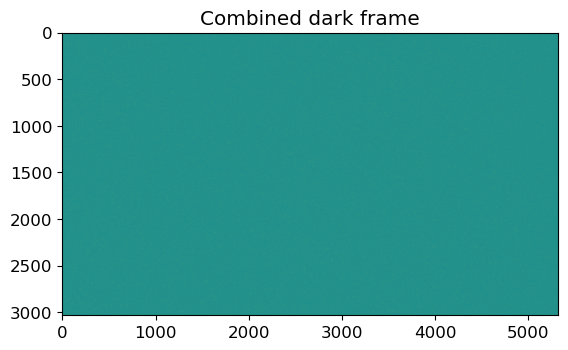

In [11]:
if processing_steps['dark']:
    if not os.path.exists(os.path.join(calibrated_data, 'dark')):
        os.makedirs(os.path.join(calibrated_data, 'dark'))

    dark_paths = [os.path.join(dark_files.location, file) for file in dark_files.files]
    print('combining dark files', dark_paths)
    combined_dark = ccdp.combine(
        dark_paths,
        output_file=os.path.join(calibrated_data, 'dark', 'combined_dark.fits'),
        overwrite_output=True,
        method='average',
        sigma_clip=True,
        sigma_clip_low_thresh=5,
        sigma_clip_high_thresh=5,
        sigma_clip_func=np.ma.median,
        sigma_clip_dev_func=mad_std,
        mem_limit=16e9,
        hdu=1
    )

    vis = True
    # Combine dark frames
    combined_dark_frame = CCDData.read(calibrated_data / 'dark' / 'combined_dark.fits')
    if vis:
        fig, ax = plt.subplots()
        ax.imshow(
            combined_dark_frame.data,
            vmin=-.4*combined_dark_frame.data.std() + np.median(combined_dark_frame.data),
            vmax=.4*combined_dark_frame.data.std() + np.median(combined_dark_frame.data)
        )
        ax.set_title('Combined dark frame')
        plt.show()

### Flat-field correction

Use flats to derive a flat-field correction.

In [12]:
# https://www.astropy.org/ccd-reduction-and-photometry-guide/v/dev/notebooks/05-04-Combining-flats.html

def inv_median(a):
    return 1 / np.median(a)

In [13]:
def true_flatfield(calibrated_data, flat_files, combined_bias, combined_dark):
    # First, subtract off dark + bias from flat frames.
    for i, flat in enumerate(flat_files.files):
        # subtract dark current and bias noise in one step
        flat_raw = CCDData.read(os.path.join(flat_files.location, flat), hdu=1)
        # flat_raw = CCDData.read(flat)
        reduced = ccdp.subtract_bias(
            flat_raw,
            combined_bias,
        )
        # reduced = ccdp.subtract_dark(
        #     reduced,
        #     combined_dark,
            # exposure_time='exptime',
            # exposure_unit=u.second
        # )
        reduced.write(calibrated_data / 'flat' / flat, format='fits', overwrite=True)
    # Combine flat frames
    if not os.path.exists(os.path.join(calibrated_data, 'flat')):
        os.makedirs(os.path.join(calibrated_data, 'flat'))
    print([os.path.join(calibrated_data, 'flat', file) for file in flat_files.files])
    combined_flat = ccdp.combine([os.path.join(calibrated_data, 'flat', file) for file in flat_files.files],
        output_file=os.path.join(calibrated_data, 'flat', 'combined_flat.fits'),
        overwrite_output=True,
        method='average',
        scale=inv_median,
        sigma_clip=True,
        sigma_clip_low_thresh=5,
        sigma_clip_high_thresh=5,
        sigma_clip_func=np.ma.median,
        signma_clip_dev_func=mad_std,
        mem_limit=16e9,
    )

    flat_data = combined_flat.data
    return flat_data


def sep_flatfield(img):
    z = img.astype(np.float64)
    opts = dict(
        # bw=78,
        # bh=78,
        # fw=16,
        # fh=16
    )
    flat_data = sep.Background(z, **opts)
    return flat_data

In [14]:
# Combine flat field data
vis = True

combined_bias = ccdp.CCDData.read(calibrated_data / 'bias' / 'combined_bias.fits')
combined_dark = ccdp.CCDData.read(calibrated_data / 'dark' / 'combined_dark.fits')

flat_data = true_flatfield(calibrated_data, flat_files, combined_bias, combined_dark)

['/home/evanmayer/TIM_data/test_events/TIMcam/flight_test/cal/flat/saved_image_2025-09-03_21-58-31.fits.fz', '/home/evanmayer/TIM_data/test_events/TIMcam/flight_test/cal/flat/saved_image_2025-09-03_21-58-33.fits.fz', '/home/evanmayer/TIM_data/test_events/TIMcam/flight_test/cal/flat/saved_image_2025-09-03_21-58-34.fits.fz', '/home/evanmayer/TIM_data/test_events/TIMcam/flight_test/cal/flat/saved_image_2025-09-03_21-58-36.fits.fz', '/home/evanmayer/TIM_data/test_events/TIMcam/flight_test/cal/flat/saved_image_2025-09-03_21-58-37.fits.fz', '/home/evanmayer/TIM_data/test_events/TIMcam/flight_test/cal/flat/saved_image_2025-09-03_21-58-39.fits.fz', '/home/evanmayer/TIM_data/test_events/TIMcam/flight_test/cal/flat/saved_image_2025-09-03_21-58-40.fits.fz', '/home/evanmayer/TIM_data/test_events/TIMcam/flight_test/cal/flat/saved_image_2025-09-03_21-58-42.fits.fz', '/home/evanmayer/TIM_data/test_events/TIMcam/flight_test/cal/flat/saved_image_2025-09-03_21-58-43.fits.fz', '/home/evanmayer/TIM_data/t

1.0


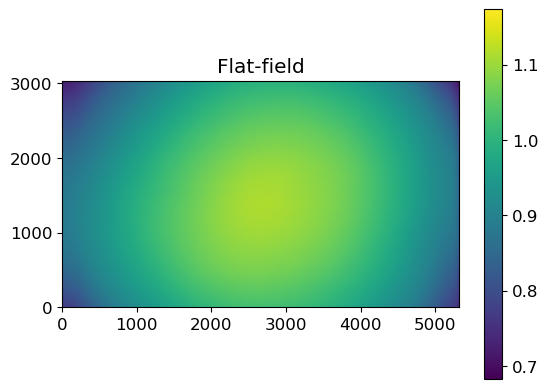

In [15]:
# scale derived flat by the median
# flat_data -= np.min(flat_data)
flat_data /= np.median(flat_data)
flat_data[flat_data < 1e-9] = np.median(flat_data)
print(np.median(flat_data))
combined_flat = CCDData(flat_data, unit='adu')

combined_flat.write(calibrated_data / 'flat' / 'scaled_flat.fits', format='fits', overwrite=True)

if vis:
    fig, ax = plt.subplots()
    im = ax.imshow(
        flat_data,
        origin='lower',
    )
    plt.colorbar(im)
    ax.set_title("Flat-field")
    plt.show()

### Finally, subtract median - (dark + bias) data, and divide out flat-field.

* Apply gain correction to convert ADU to e-
* Divide by exposure time to get e-/s
* Look up WCS solution from preprocessing and apply to the file

Save off corrected frames in the reduced data directory.

In [16]:
def calibrate(file):
    sci = file
    # subtract dark current and bias noise in one step
    sci_raw = CCDData.read(sci, hdu=1)
    combined_dark = ccdp.CCDData.read(calibrated_data / 'dark' / 'combined_dark.fits')
    reduced = ccdp.subtract_dark(
        sci_raw,
        combined_dark,
        exposure_time='EXPTIME',
        exposure_unit=u.second,
    )

    # divide out flat field
    combined_flat = ccdp.CCDData.read(calibrated_data / 'flat' / 'scaled_flat.fits')
    reduced = ccdp.flat_correct(reduced, combined_flat)

    # convert to electrons/s from ADUs
    # https://thinklucid.com/product/triton-16-2-mp-imx542/?srsltid=AfmBOorWeS_UYDtT8ZuoNhhgyEVhc7NRxoBQiFOYLiM8PHZ1PaTqk6eL
    # base_gain = 0.42 # DN/e-, also broadly consistent with N grey levels / full well e-
    # base_gain = (1. / 2.310791016) # DN/e-, from Lucid. WRONG WRONG WRONG IDS IS A LIAR SOMETIMES
    base_gain = 0.165 # DN / e-, avg of gain derived using photon transfer curve method on difference images at float
    gainfact = reduced.header['GAINFACT']
    total_gain_e_per_adu = (1. / (base_gain * gainfact)) * u.electron / u.adu / u.s
    reduced = ccdp.gain_correct(reduced, total_gain_e_per_adu)
    exptime = reduced.header['EXPTIME']
    reduced.data /= exptime

    # for storage
    reduced.data = reduced.data.astype(np.uint16)

    # try to use cached plate solve from initial data processing
    wcs_file = os.path.basename(sci).replace('.fits.fz', '_funpack.wcs')
    if os.path.exists(wcs_dir + wcs_file):
        with fits.open(wcs_dir + wcs_file) as f:
            h = f[0].header
        wcs = WCS(header=h)
        reduced.wcs = wcs
    # merge_wcs(calibrated_data / 'sci' / sci, wcs)

    # save reduced file
    # print('Successfully reduced', sci, ', saving to', calibrated_data / 'sci' / os.path.basename(sci), end='\r')
    print(f'{list(sci_files.files).index(sci) / len(sci_files.files):.3f}')
    # for storage, throw away mask and uncert HDUs
    reduced.to_hdu()[0].writeto(calibrated_data / 'sci' / os.path.basename(sci), overwrite=True)

In [17]:
len(sci_files.files)

137

In [18]:
from multiprocessing import Pool

with Pool(6) as p:
    p.map(calibrate, sci_files.files)

0.044


0.175


0.000


0.219


0.131


0.088
0.051
0.182
0.007
0.226
0.139
0.095
0.058
0.190
0.015
0.234
0.102
0.146
0.197
0.066
0.022
0.241
0.153
0.109
0.073
0.204
0.029
0.248
0.161
0.117
0.080
0.212
0.036
0.255
0.168
0.124
0.263
0.307
0.350
0.394
0.438
0.482
0.314
0.270
0.358
0.401
0.489
0.445
0.321
0.365
0.277
0.409
0.496
0.453
0.328
0.372
0.416
0.285
0.504
0.460
0.336
0.380
0.423
0.292
0.467
0.511
0.343
0.387
0.431
0.299
0.474
0.518
0.526
0.569
0.613
0.657
0.745
0.701
0.533
0.577
0.664
0.620
0.752
0.540
0.708
0.584
0.672
0.628
0.759
0.715
0.547
0.591
0.679
0.635
0.766
0.723
0.555
0.599
0.686
0.642
0.774
0.730
0.562
0.606
0.650
0.693
0.781
0.737
0.788
0.832
0.876
0.920
0.964
0.796
0.839
0.883
0.927
0.971
0.803
0.847
0.934
0.891
0.978
0.810
0.854
0.942
0.898
0.985
0.818
0.861
0.949
0.993
0.905
0.825
0.869
0.956
0.912


In [19]:
# sci_cal = ccdp.ImageFileCollection('/home/evanmayer/TIM_data/test_events/TIMcam/flight_test/cal/sci/', glob_include=f'*.fits.fz')
# print(len(sci_cal.files))